# Exploratory Data Analysis

Explore `dataset.csv` produced by notebook 02 (or script 03).

**Goals:**
1. Class balance (CC vs NC, flavour composition).
2. Feature distributions split by CC/NC and by flavour.
3. Correlation structure across detector observables.
4. Reconstruction quality: truth vs reco for energy, zenith, baseline `L`.
5. Sanity-check identification of useful features for the ML notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('dataset.csv')
print(f'Loaded dataset.csv: {len(df):,} rows x {df.shape[1]} columns')

Loaded dataset.csv: 1,000 rows x 44 columns


## 1. Class balance

Atmospheric neutrino interactions split into Charged Current (CC, has a charged lepton in the final state) and Neutral Current (NC, no charged lepton -- the neutrino bounces and stays a neutrino).

Within CC, the lepton flavour identifies the incoming neutrino flavour.

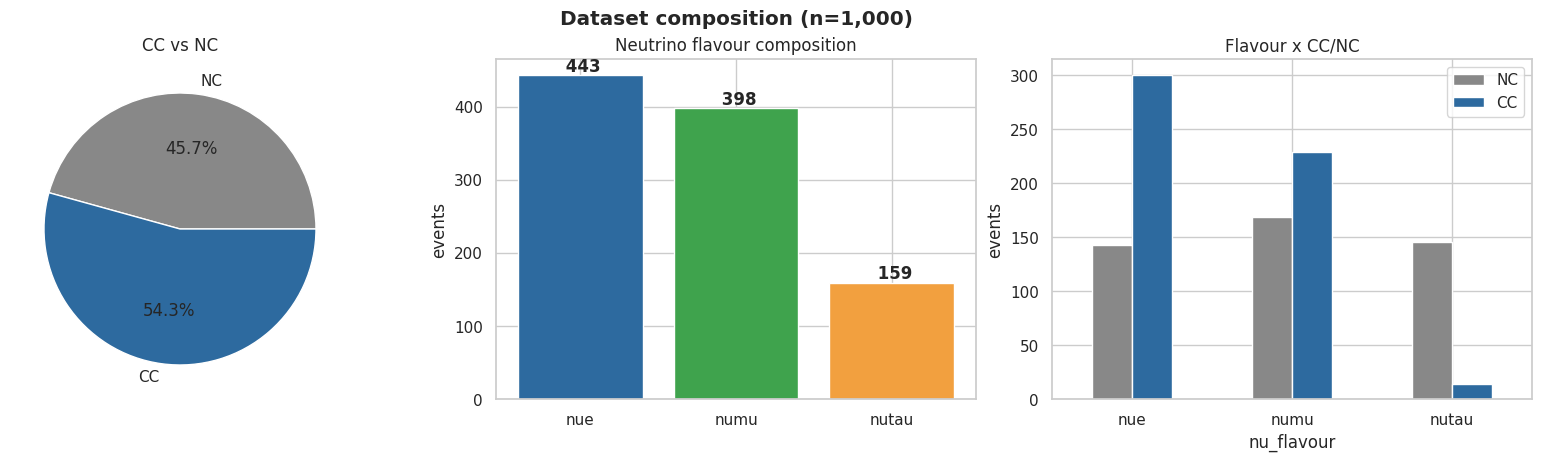

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# CC vs NC
cc_counts = df['is_cc'].value_counts().sort_index()
axes[0].pie(cc_counts.values, labels=['NC','CC'], autopct='%1.1f%%',
            colors=['#888','#2D6A9F'], wedgeprops={'edgecolor':'white'})
axes[0].set_title('CC vs NC')

# Flavour overall
flav_counts = df['nu_flavour'].value_counts()
axes[1].bar(flav_counts.index, flav_counts.values,
            color=['#2D6A9F','#3FA34D','#F2A03F'])
for i, v in enumerate(flav_counts.values):
    axes[1].text(i, v, f' {v}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Neutrino flavour composition')
axes[1].set_ylabel('events')

# Flavour x CC/NC
ct = pd.crosstab(df['nu_flavour'], df['is_cc'])
ct.columns = ['NC','CC']
ct.plot(kind='bar', stacked=False, ax=axes[2],
        color=['#888','#2D6A9F'], edgecolor='white')
axes[2].set_title('Flavour x CC/NC')
axes[2].set_ylabel('events')
axes[2].legend(title='')
axes[2].set_xticklabels(ct.index, rotation=0);

fig.suptitle(f'Dataset composition (n={len(df):,})', fontweight='bold');

## 2. Detector-observable distributions, CC vs NC

How NC and CC events differ at the level of pure detector readout (no MC truth used).

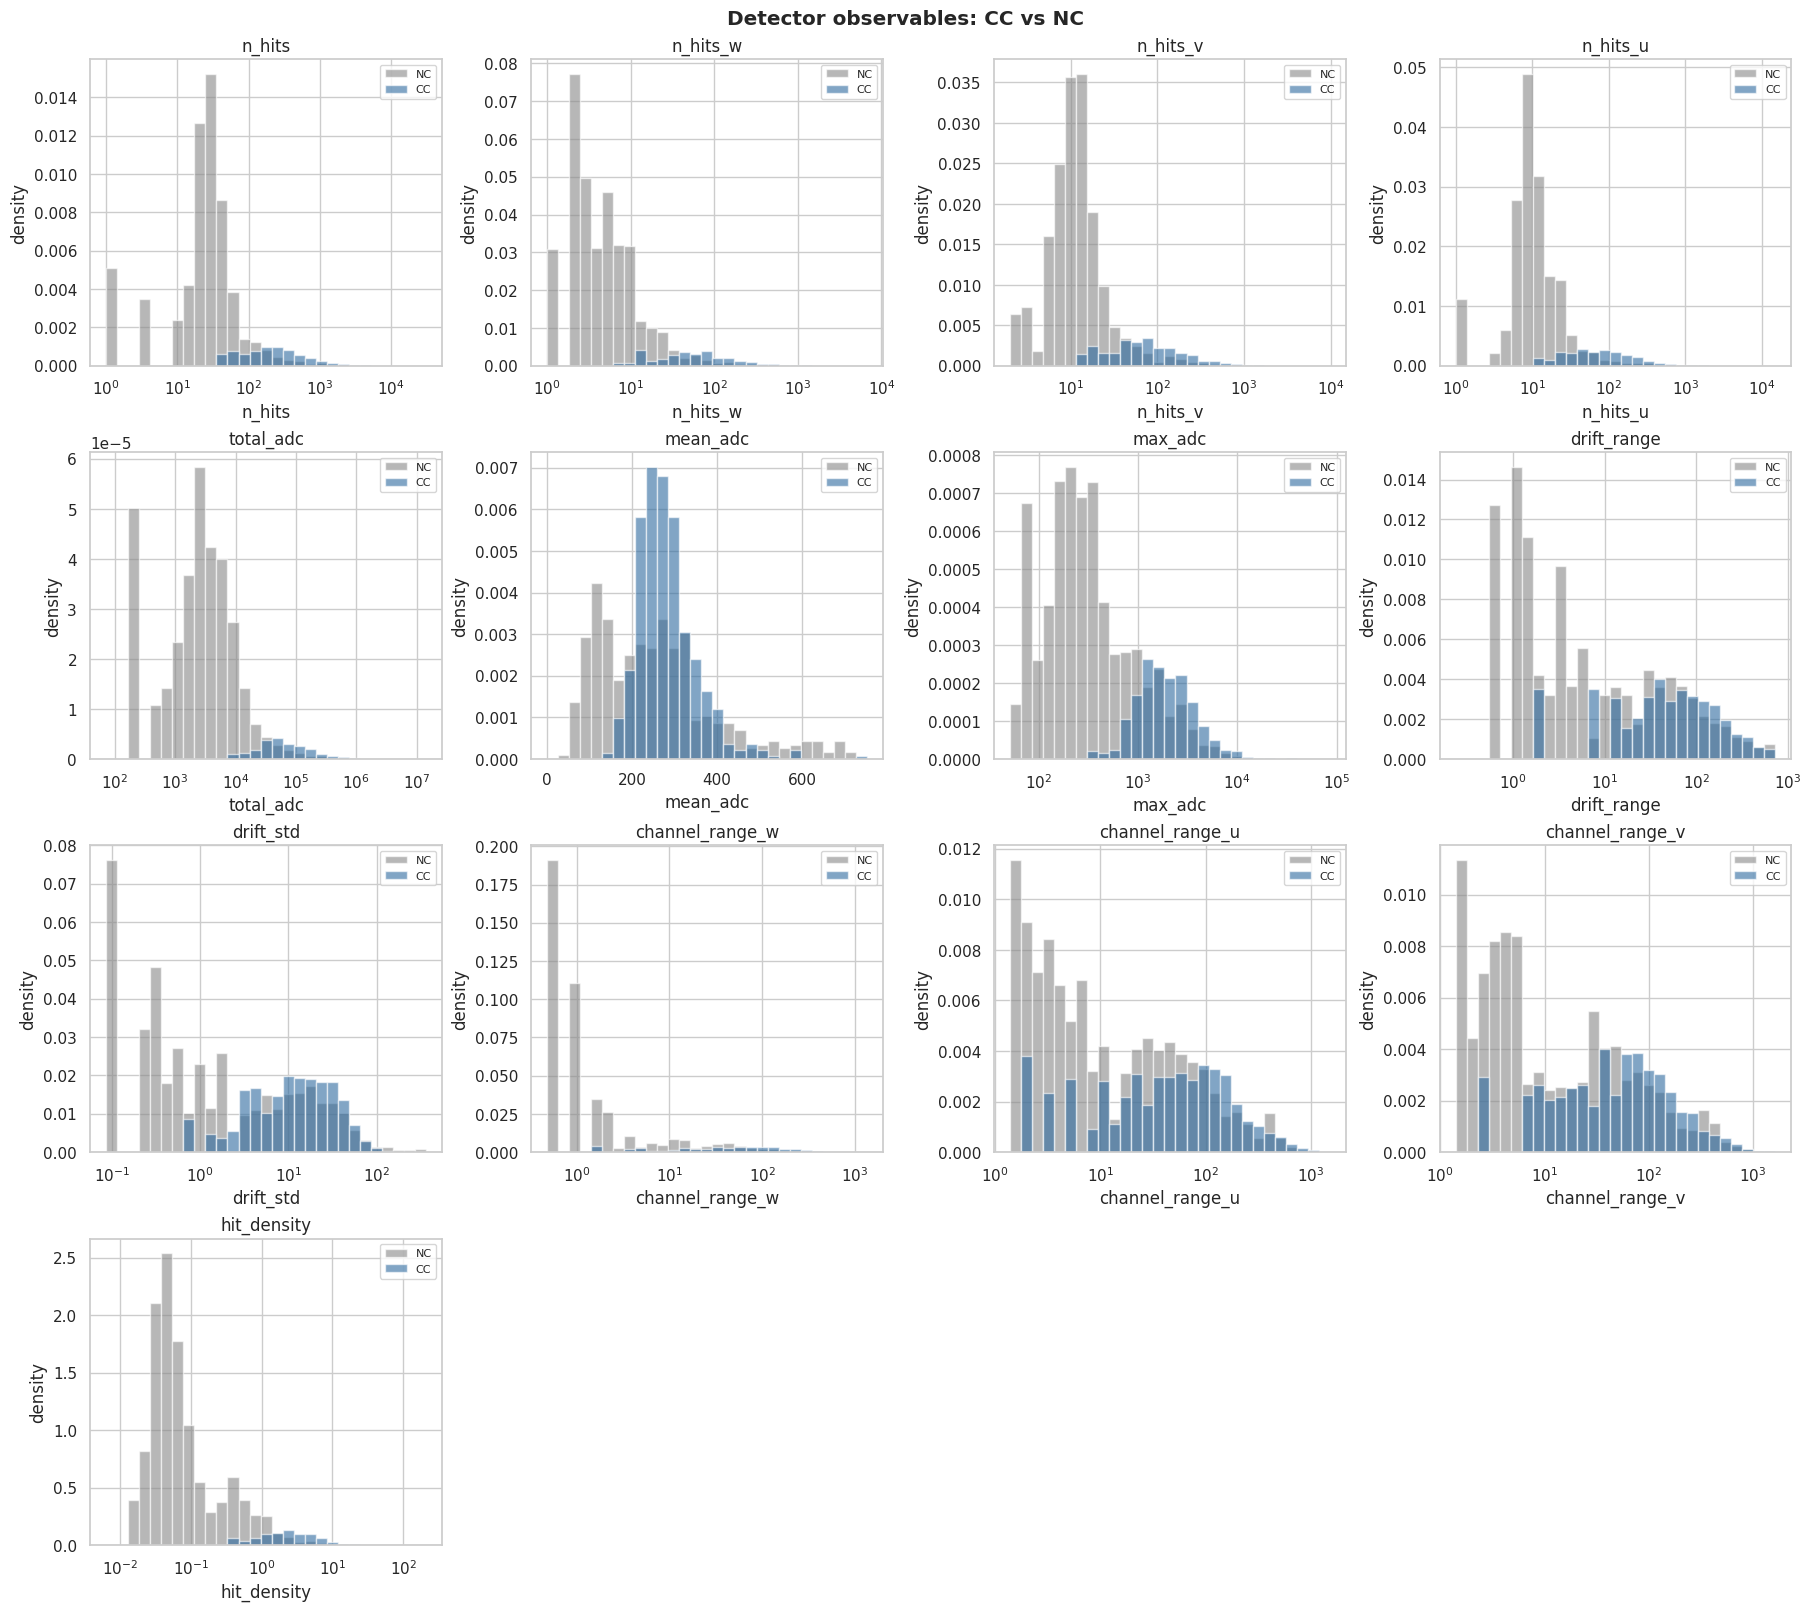

In [3]:
obs_cols = ['n_hits','n_hits_w','n_hits_v','n_hits_u',
            'total_adc','mean_adc','max_adc',
            'drift_range','drift_std',
            'channel_range_w','channel_range_u','channel_range_v','hit_density']

fig, axes = plt.subplots(4, 4, figsize=(18, 16), constrained_layout=True)
axes = axes.flatten()

cc = df[df['is_cc']]; nc = df[~df['is_cc']]

for ax, col in zip(axes, obs_cols):
    # Choose log scale if range > 100x
    vals = df[col].dropna()
    use_log = vals.max() / max(vals.replace(0, np.nan).min(), 1e-6) > 100
    bins = np.logspace(np.log10(max(vals.replace(0, np.nan).min(), 1e-3)),
                       np.log10(vals.max() + 1), 30) if use_log \
           else np.linspace(0, np.percentile(vals, 99), 30)
    ax.hist(nc[col].dropna(), bins=bins, density=True, color='#888',
            alpha=0.6, label='NC')
    ax.hist(cc[col].dropna(), bins=bins, density=True, color='#2D6A9F',
            alpha=0.6, label='CC')
    if use_log: ax.set_xscale('log')
    ax.set_xlabel(col); ax.set_ylabel('density'); ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axes[len(obs_cols):]:
    ax.axis('off')

fig.suptitle('Detector observables: CC vs NC', fontweight='bold');

## 3. Detector observables by neutrino flavour (CC events only)

Within CC events, do `nue`, `numu`, and `nutau` look different in the detector? They should -- electrons make showers, muons make long tracks, taus produce kinky tracks.

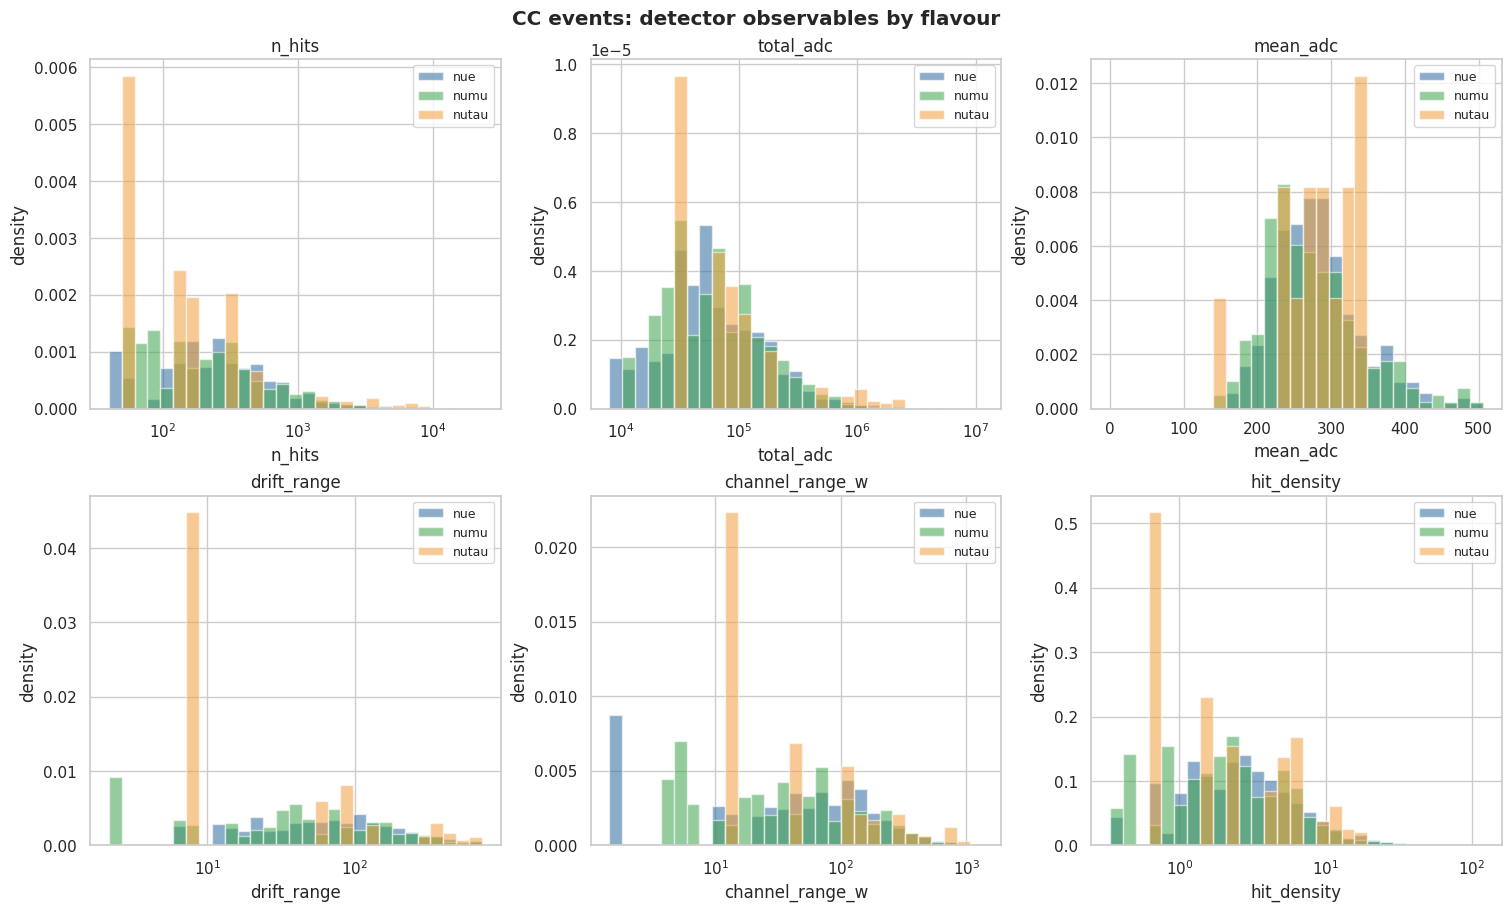

In [4]:
cc_only = df[df['is_cc']].copy()
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.flatten()

key_cols = ['n_hits','total_adc','mean_adc','drift_range','channel_range_w','hit_density']
flav_colors = {'nue':'#2D6A9F','numu':'#3FA34D','nutau':'#F2A03F'}

for ax, col in zip(axes, key_cols):
    vals = cc_only[col].dropna()
    use_log = vals.max() / max(vals.replace(0, np.nan).min(), 1e-6) > 100
    bins = np.logspace(np.log10(max(vals.replace(0,np.nan).min(),1e-3)),
                       np.log10(vals.max()+1), 30) if use_log \
           else np.linspace(0, np.percentile(vals,99), 30)
    for flav, c in flav_colors.items():
        sub = cc_only[cc_only['nu_flavour']==flav][col].dropna()
        if len(sub) == 0: continue
        ax.hist(sub, bins=bins, density=True, color=c, alpha=0.55, label=flav)
    if use_log: ax.set_xscale('log')
    ax.set_xlabel(col); ax.set_ylabel('density'); ax.set_title(col)
    ax.legend(fontsize=9)

fig.suptitle('CC events: detector observables by flavour', fontweight='bold');

## 4. Truth-level kinematic distributions

What do the *true* neutrino energies and zenith angles look like? This is the underlying physics we're trying to access.

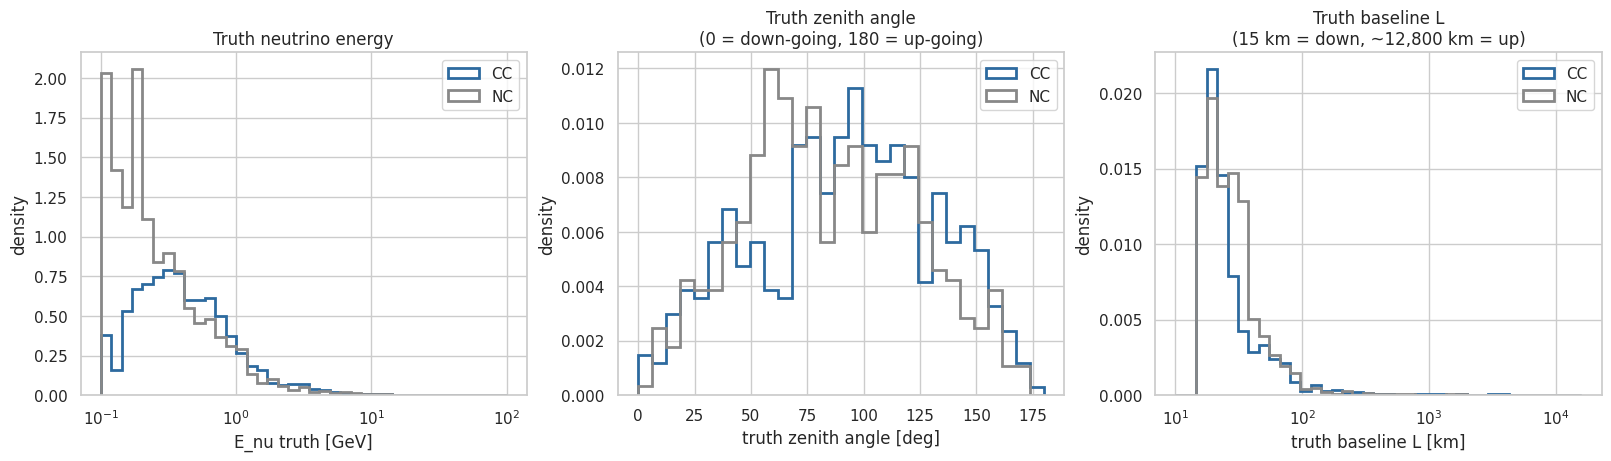

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# Truth energy
for is_cc, label, col in [(True, 'CC', '#2D6A9F'), (False, 'NC', '#888')]:
    sub = df[df['is_cc']==is_cc]['nu_energy_truth'].dropna()
    axes[0].hist(sub, bins=np.logspace(-1, 2, 40), histtype='step',
                 lw=2, color=col, label=label, density=True)
axes[0].set_xscale('log'); axes[0].set_xlabel('E_nu truth [GeV]')
axes[0].set_ylabel('density'); axes[0].set_title('Truth neutrino energy')
axes[0].legend()

# Truth zenith
for is_cc, label, col in [(True, 'CC', '#2D6A9F'), (False, 'NC', '#888')]:
    sub = df[df['is_cc']==is_cc]['zenith_truth_deg'].dropna()
    axes[1].hist(sub, bins=np.linspace(0, 180, 30), histtype='step',
                 lw=2, color=col, label=label, density=True)
axes[1].set_xlabel('truth zenith angle [deg]')
axes[1].set_ylabel('density')
axes[1].set_title('Truth zenith angle\n(0 = down-going, 180 = up-going)')
axes[1].legend()

# Truth baseline L
for is_cc, label, col in [(True, 'CC', '#2D6A9F'), (False, 'NC', '#888')]:
    sub = df[df['is_cc']==is_cc]['L_truth_km'].dropna()
    axes[2].hist(sub, bins=np.logspace(1, 4.2, 40), histtype='step',
                 lw=2, color=col, label=label, density=True)
axes[2].set_xscale('log'); axes[2].set_xlabel('truth baseline L [km]')
axes[2].set_ylabel('density'); axes[2].set_title('Truth baseline L\n(15 km = down, ~12,800 km = up)')
axes[2].legend();

## 5. Reconstruction quality: truth vs reco

How well does our pipeline reconstruct the neutrino kinematics? CC events with successful 3D reconstruction only.

CC events with successful direction reconstruction: 151 / 543


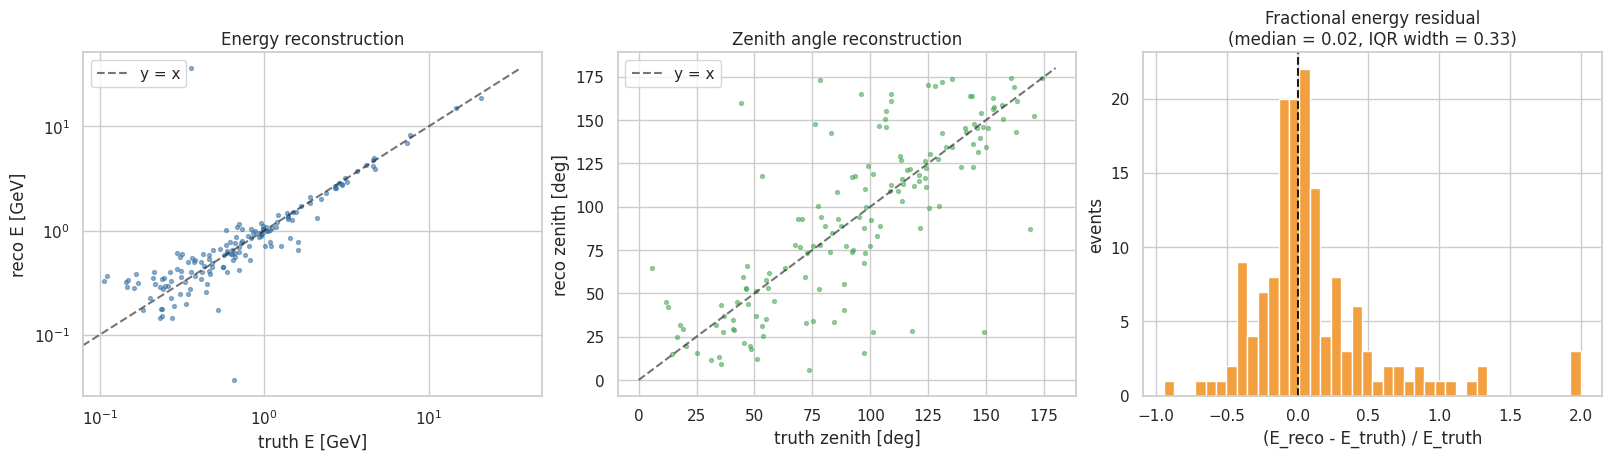

In [6]:
ok = df[df['direction_recon_ok'] & df['is_cc']].copy()
print(f'CC events with successful direction reconstruction: {len(ok)} / {df["is_cc"].sum()}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

axes[0].scatter(ok['nu_energy_truth'], ok['nu_energy_reco'], s=8, alpha=0.5, c='#2D6A9F')
lims = [0, max(ok['nu_energy_truth'].max(), ok['nu_energy_reco'].max())]
axes[0].plot(lims, lims, 'k--', alpha=0.6, label='y = x')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('truth E [GeV]'); axes[0].set_ylabel('reco E [GeV]')
axes[0].set_title('Energy reconstruction')
axes[0].legend()

axes[1].scatter(ok['zenith_truth_deg'], ok['zenith_reco_deg'], s=8, alpha=0.5, c='#3FA34D')
axes[1].plot([0,180],[0,180], 'k--', alpha=0.6, label='y = x')
axes[1].set_xlabel('truth zenith [deg]'); axes[1].set_ylabel('reco zenith [deg]')
axes[1].set_title('Zenith angle reconstruction')
axes[1].legend()

# Energy residual histogram
res = (ok['nu_energy_reco'] - ok['nu_energy_truth']) / ok['nu_energy_truth']
axes[2].hist(res.clip(-2, 2), bins=40, color='#F2A03F', edgecolor='white')
axes[2].axvline(0, color='k', ls='--')
axes[2].set_xlabel('(E_reco - E_truth) / E_truth')
axes[2].set_ylabel('events')
axes[2].set_title(f'Fractional energy residual\n(median = {res.median():.2f}, IQR width = {res.quantile(0.75)-res.quantile(0.25):.2f})');

## 6. Correlation heatmap (detector observables only, no truth)

Which observables carry redundant information? Highly correlated features add little to a tree model and can confuse linear models.

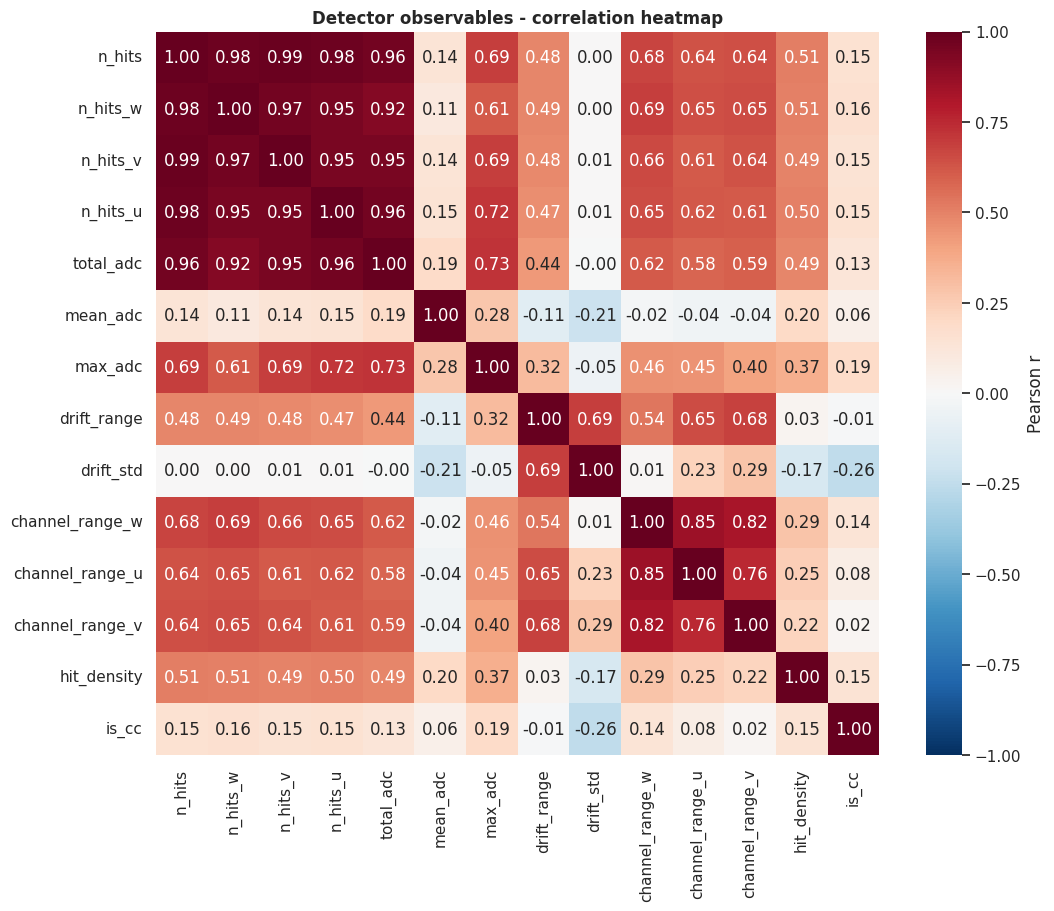

In [7]:
obs_cols_for_corr = ['n_hits','n_hits_w','n_hits_v','n_hits_u',
                     'total_adc','mean_adc','max_adc',
                     'drift_range','drift_std',
                     'channel_range_w','channel_range_u','channel_range_v',
                     'hit_density']

corr = df[obs_cols_for_corr + ['is_cc']].astype(float).corr()
fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label':'Pearson r'})
ax.set_title('Detector observables - correlation heatmap', fontweight='bold');

## 7. Topology features

How do the primary-particle counts differ between CC and NC?

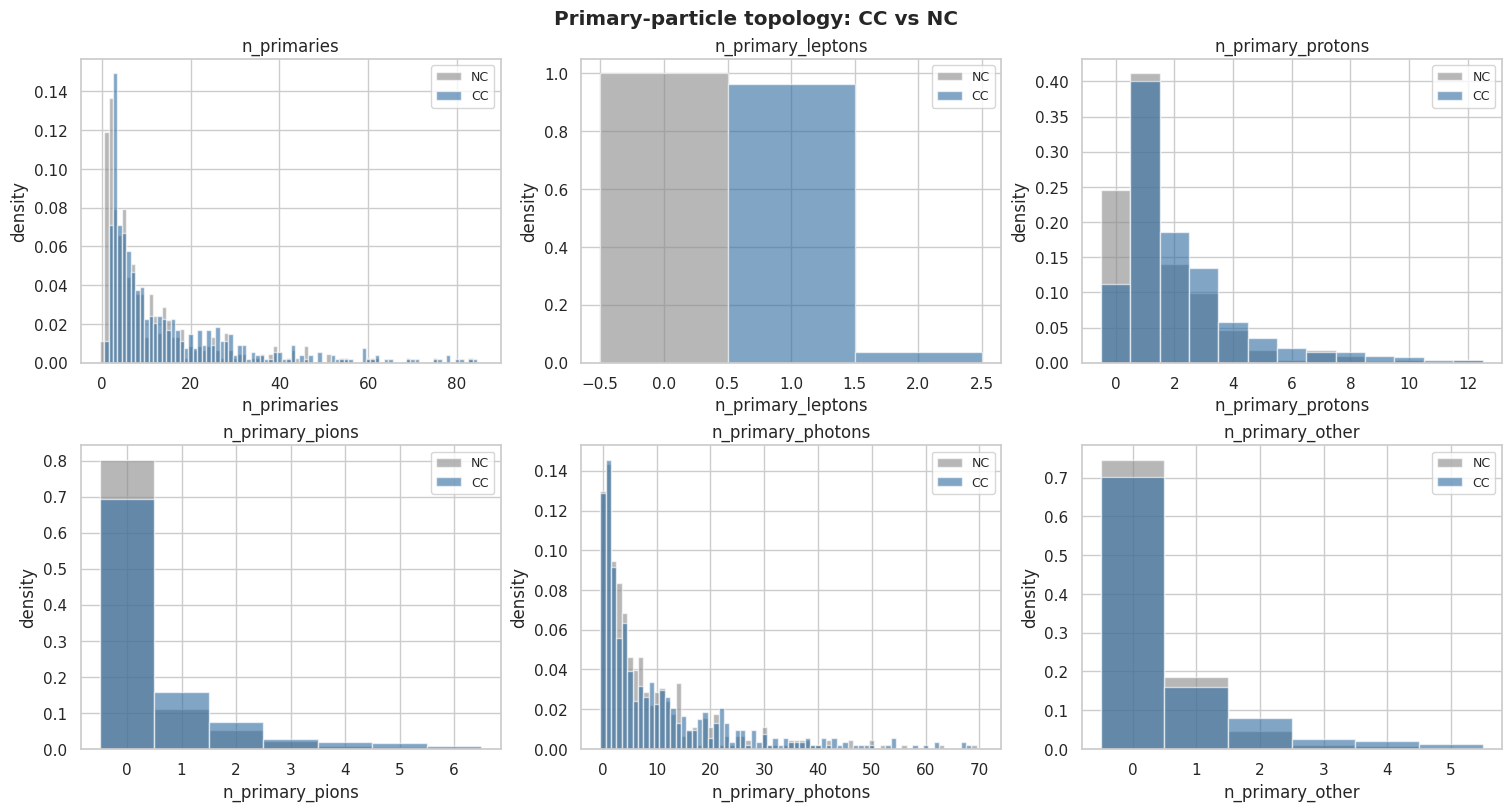

In [8]:
topo_cols = ['n_primaries','n_primary_leptons','n_primary_protons',
             'n_primary_pions','n_primary_photons','n_primary_other']
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes = axes.flatten()

for ax, col in zip(axes, topo_cols):
    cc_vals = df[df['is_cc']][col]
    nc_vals = df[~df['is_cc']][col]
    bins = np.arange(0, max(df[col].quantile(0.99), 1) + 2) - 0.5
    ax.hist(nc_vals, bins=bins, density=True, color='#888', alpha=0.6, label='NC')
    ax.hist(cc_vals, bins=bins, density=True, color='#2D6A9F', alpha=0.6, label='CC')
    ax.set_xlabel(col); ax.set_ylabel('density'); ax.set_title(col)
    ax.legend(fontsize=9)

fig.suptitle('Primary-particle topology: CC vs NC', fontweight='bold');

## Takeaways for the ML notebook

From the EDA above, the features that show clear CC/NC separation are typically:
- **n_hits** and per-plane hit counts (CC events tend to have more hits because of the lepton track)
- **drift_range** and **channel_range_*** (lepton tracks elongate the event in space)
- **total_adc** and **max_adc** (charge deposition follows)
- **n_primaries** (truth-only, but useful as a sanity check)

For flavour discrimination within CC, the relevant variables are more subtle (track topology, hit density along the track), and a tabular model will struggle compared to a CNN -- but we'll quantify exactly how much in the next notebook.